In [66]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [67]:
plt.rcParams['figure.figsize'] = [15, 5]
sns.set_style('whitegrid')

In [68]:
def read_image(path):
    """
    OpenCV читає у BGR.
    Перетворюємо у RGB та float32.
    """

    image = cv2.imread(path)

    if image is None:
        raise ValueError("Image not found.")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = image.astype(np.float32)

    return image


def show_images(images, titles):
    plt.figure(figsize=(18,6))

    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)

        plt.imshow(np.clip(img / 255.0, 0, 1))
        plt.title(title)
        plt.axis("off")

    plt.show()

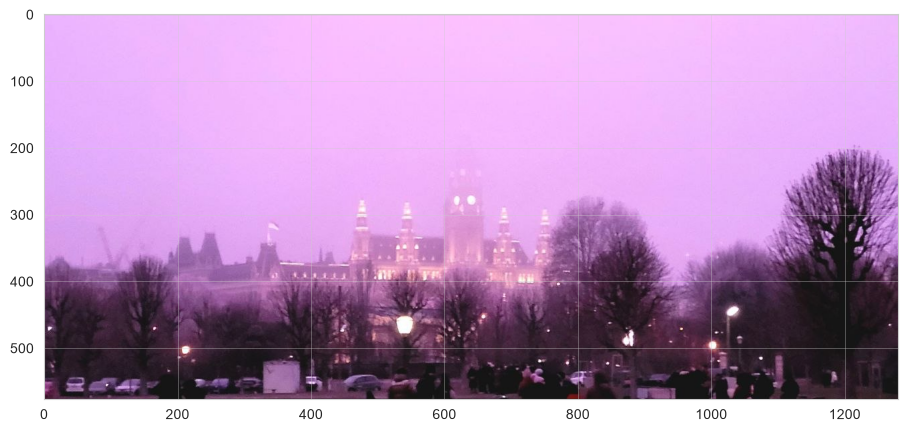

In [69]:
path = '../../../images/Vien_overexposure.jpg'
img = cv2.imread(path, flags=cv2.IMREAD_COLOR_RGB)
plt.imshow(img)
plt.show()

In [70]:
red, green, blue = cv2.split(img)

([<matplotlib.lines.Line2D at 0x1ce4388b610>], None)

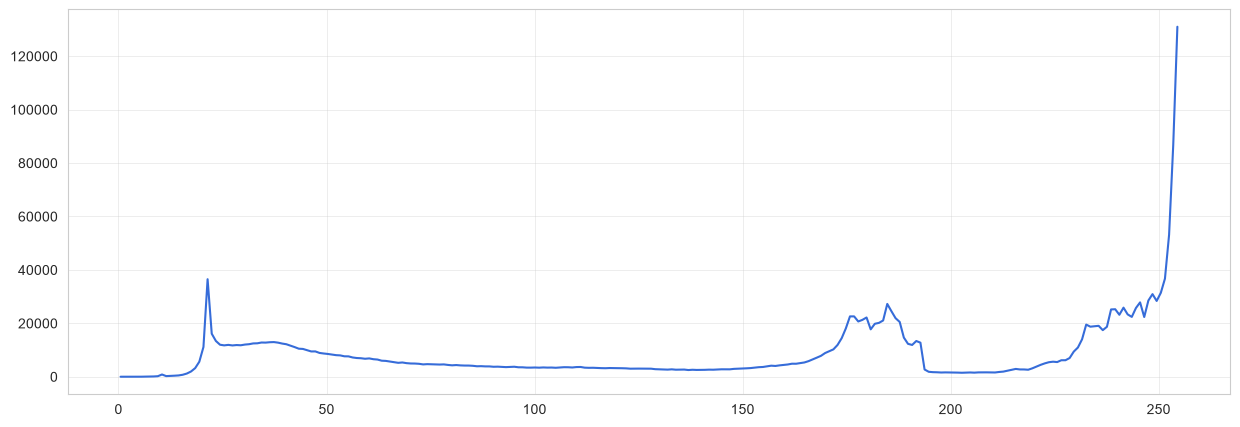

In [71]:
hist, bins = np.histogram(img.ravel(), bins=256, range=(0,255))
plt.plot(bins[0:-1]+0.5, hist), plt.grid(True)

In [72]:
# Equalize luma only
image_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
hue, saturation, value = cv2.split(image_hsv)

equalized_value = cv2.equalizeHist(value)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
clahe_value = clahe.apply(value)

equalized_out = cv2.cvtColor(cv2.merge([hue, saturation, equalized_value]), cv2.COLOR_HSV2RGB)
clahe_out = cv2.cvtColor(cv2.merge([hue, saturation, clahe_value]), cv2.COLOR_HSV2RGB)

(<Axes: title={'center': 'CLAHE'}>,
 (np.float64(-0.5), np.float64(1279.5), np.float64(576.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'CLAHE'))

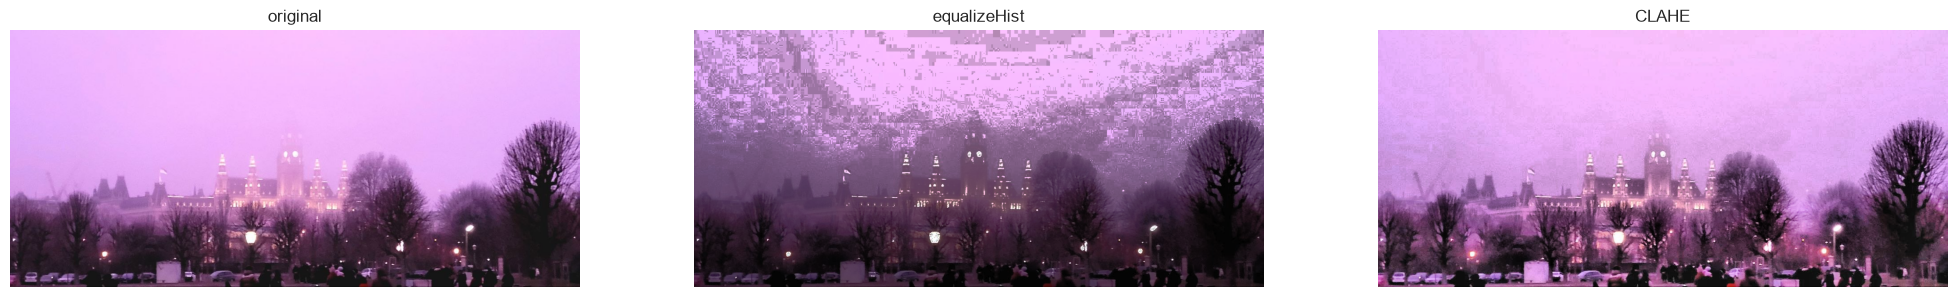

In [73]:
plt.rcParams['figure.figsize'] = [25, 15]

plt.subplot(1,3,1), plt.imshow(img), plt.axis(False), plt.title('original')
plt.subplot(1,3,2), plt.imshow(equalized_out), plt.axis(False), plt.title('equalizeHist')
plt.subplot(1,3,3), plt.imshow(clahe_out), plt.axis(False), plt.title('CLAHE')

([<matplotlib.lines.Line2D at 0x1ce43fb4a50>], None)

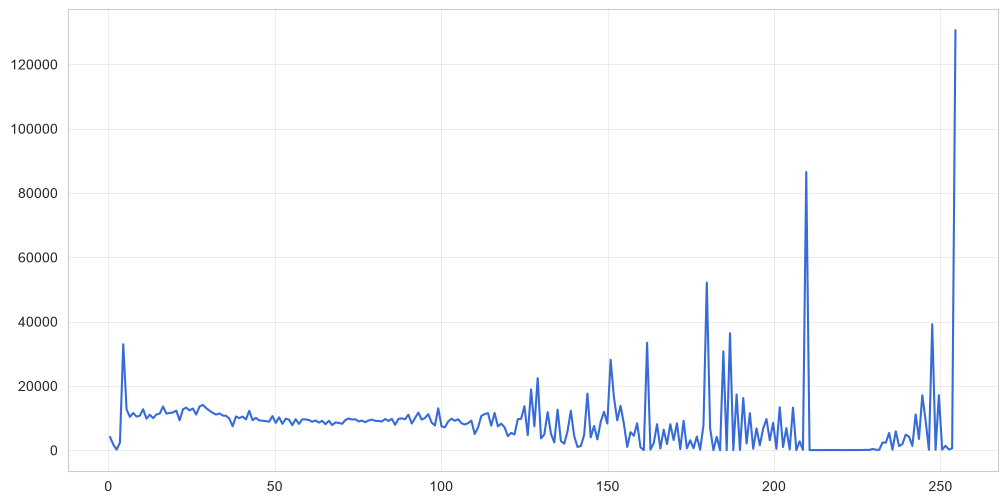

In [74]:
plt.rcParams['figure.figsize'] = [12, 6]

hist, bins = np.histogram(equalized_out.ravel(), bins=256, range=(0,255))
plt.plot(bins[0:-1]+0.5, hist), plt.grid(True)

## Balancing

- Gray-World-Algorithm
- Scale-By-Max-Algorithm
- WhitePatch-Algorithm

In [75]:
path = '../../../images/everest.jpg'
img = read_image(path)

### White patch
In white patch algorithm we choose a group of pixels we know they should be white. We then scale the resulting image colour channels by this white patch.

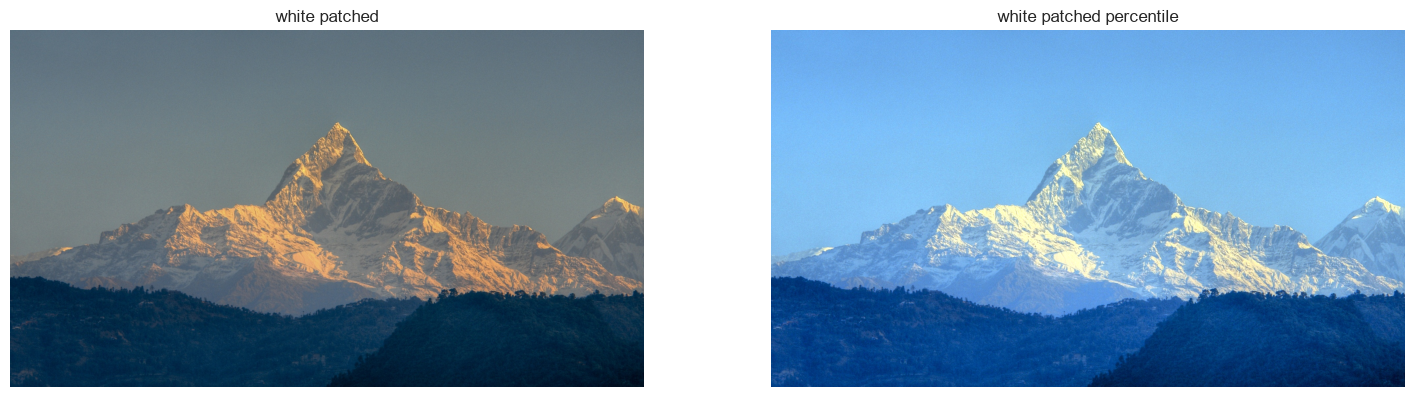

In [76]:
def white_patch_percentile(image, percentile=99):

    img = image.copy()

    white = np.percentile(
        img.reshape(-1,3),
        percentile,
        axis=0
    )

    scales = 255.0 / white

    img *= scales

    return np.clip(img,0,255)

white_patched = white_patch_percentile(img)

show_images([img, white_patched], ['white patched', 'white patched percentile'])

### Gray world
This algorithm assumes that a scene, on average, is gray.

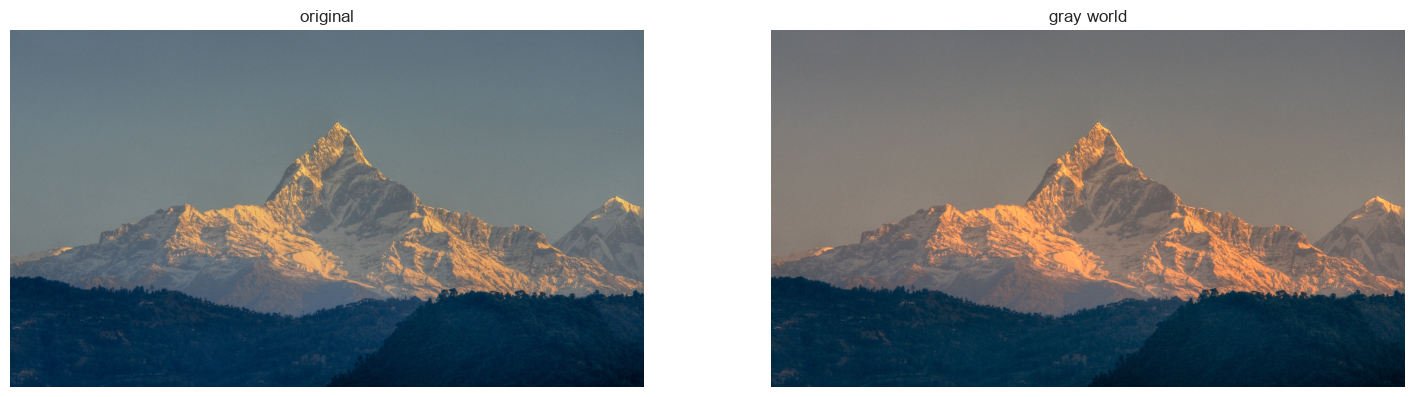

In [77]:

def gray_world(image):

    img = image.copy()

    means = img.reshape(-1,3).mean(axis=0)

    gray = means.mean()

    scales = gray / means

    img *= scales

    return np.clip(img,0,255)

gray_wrld_balanced = gray_world(img)

show_images([img, gray_wrld_balanced], ['original', 'gray world'])

### Scale-by-max
This is a straightforward algorithm that scales each colour channel by its maximum value. Note that it is sensitive to noise and saturations.

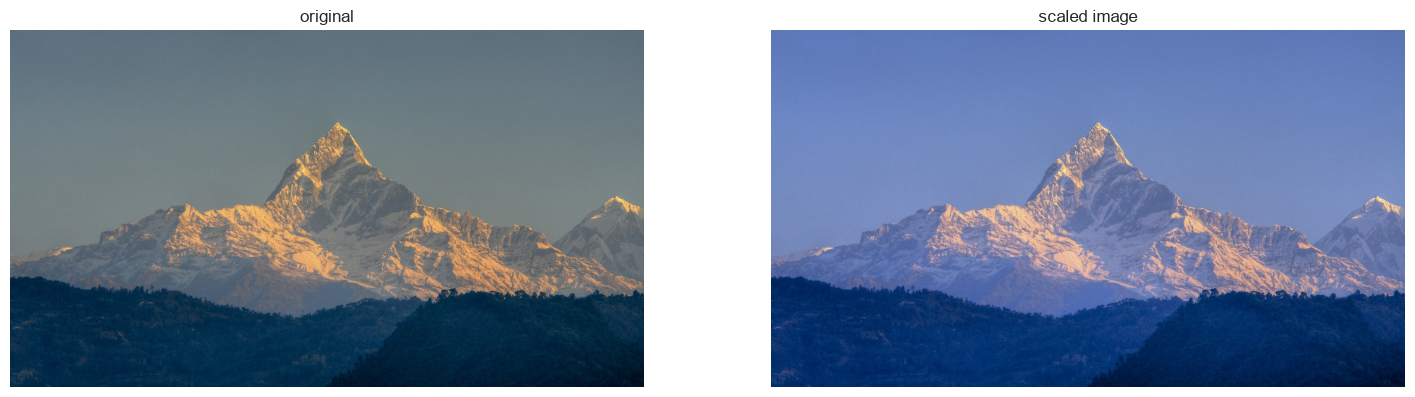

In [78]:
def scale_by_max(image):

    img = image.copy()

    for c in range(3):

        channel = img[:, :, c]

        maximum = channel.max()

        if maximum > 0:
            img[:, :, c] = channel * (255.0 / maximum)

    return np.clip(img, 0, 255)

scaled_img = scale_by_max(img)

show_images([img, scaled_img], ['original', 'scaled image'])